# Grover search

Unstructured search over $N=2^n$ addresses costs $O(\sqrt{N})$ oracle
queries. One Grover iterate is

$$
G = (2|s\rangle\langle s|-I)\,O_f
$$

where $|s\rangle$ is the uniform superposition and $O_f$ phase-flips
the marked item.

Here $n=3$, $N=8$, the marked state is $|101\rangle$, and the optimal
iteration count is $\lfloor \pi/4\sqrt{8}\rfloor = 2$.

Oracle and diffuser are written out as gates. This notebook does not
import the Shor example.

In [1]:
import math
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

N = 3
MARKED = "101"
print("optimal k =", int(math.floor(math.pi / 4 * math.sqrt(2 ** N))))

optimal k = 2


## Phase oracle

Flip every qubit that should be $0$ in the marked string, apply a
multi-controlled $Z$ (H–MCX–H on the last qubit), then undo the flips.

In [2]:
def oracle(marked):
    qc = QuantumCircuit(N, name="oracle")
    zeros = [i for i, bit in enumerate(reversed(marked)) if bit == "0"]
    for q in zeros:
        qc.x(q)
    qc.h(N - 1)
    qc.mcx(list(range(N - 1)), N - 1)
    qc.h(N - 1)
    for q in zeros:
        qc.x(q)
    return qc

print(oracle(MARKED).draw())

                    
q_0: ───────■───────
     ┌───┐  │  ┌───┐
q_1: ┤ X ├──■──┤ X ├
     ├───┤┌─┴─┐├───┤
q_2: ┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘


## Diffuser $2|s\rangle\langle s|-I$

In [3]:
def diffuser(n):
    qc = QuantumCircuit(n, name="diffuser")
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))
    return qc

print(diffuser(N).draw())

     ┌───┐┌───┐          ┌───┐┌───┐     
q_0: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_1: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐
q_2: ┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘


## How the marked amplitude grows

In [4]:
def marked_probability(k):
    qc = QuantumCircuit(N)
    qc.h(range(N))
    for _ in range(k):
        qc.compose(oracle(MARKED), inplace=True)
        qc.compose(diffuser(N), inplace=True)
    return Statevector.from_instruction(qc).probabilities_dict().get(MARKED, 0.0)

for k in range(0, 5):
    print(f"k={k}  p={marked_probability(k):.3f}")

k=0  p=0.125
k=1  p=0.781
k=2  p=0.945
k=3  p=0.330
k=4  p=0.012


## Sample the optimal circuit

     ┌───┐          ┌───┐┌───┐               ┌───┐┌───┐               ┌───┐»
q_0: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├────────────■──┤ H ├»
     ├───┤┌───┐  │  ├───┤├───┤┌───┐       │  ├───┤├───┤┌───┐       │  ├───┤»
q_1: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├»
     ├───┤├───┤┌─┴─┐├───┤├───┤├───┤┌───┐┌─┴─┐├───┤├───┤├───┤┌───┐┌─┴─┐├───┤»
q_2: ┤ H ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├»
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
c: 3/══════════════════════════════════════════════════════════════════════»
                                                                           »
«     ┌───┐               ┌───┐┌───┐     ┌─┐      
«q_0: ┤ X ├────────────■──┤ X ├┤ H ├─────┤M├──────
«     ├───┤┌───┐       │  ├───┤├───┤     └╥┘┌─┐   
«q_1: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────╫─┤M├───
«     ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐ ║ └╥┘┌─┐
«q_2: ┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─╫──╫─┤M├
«

{'111': 20, '011': 13, '100': 15, '000': 12, '010': 22, '110': 19, '001': 20, '101': 1879}


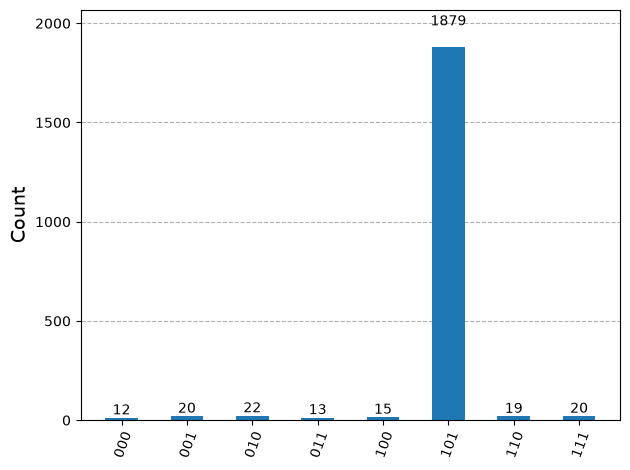

In [5]:
k_star = int(math.floor(math.pi / 4 * math.sqrt(2 ** N)))
qc = QuantumCircuit(N, N)
qc.h(range(N))
for _ in range(k_star):
    qc.compose(oracle(MARKED), inplace=True)
    qc.compose(diffuser(N), inplace=True)
qc.measure(range(N), range(N))
print(qc.draw())
counts = AerSimulator().run(transpile(qc, AerSimulator()), shots=2000).result().get_counts()
print(counts)
plot_histogram(counts)